# EXPLORATORY DATA ANALYSIS (EDA)
## Exploring Sales Trends and Integrating External Data for Market Expansion

This notebook is divided into 4 main sections:
1. **Part 1: Raw Data Visualization**: Exploring the initial state of the Olist dataset.
2. **Part 2: Processed Data Visualization**: Using cleaned data tables after preprocessing to accurately evaluate successful revenue.
3. **Part 3: External Data Integration**: Combining with Brazil's demographic data (Population & GDP) for market analysis.
4. **Part 4: Brazil Geospatial Mapping**: Drawing choropleth maps to visualize revenue distribution and market penetration opportunities across Brazil's geographic boundaries.


In [1]:
# ============================================================
# 1. LIBRARY SETUP & PATH CONFIGURATION
# ============================================================
import os
import sys
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from src.olist_pipeline.utils.system_utils import project_root

try:
    from IPython.display import display
except ImportError:
    display = print

# Configure font and style for better-looking charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['font.size'] = 10

olist_raw_dir = project_root / "data/raw/olist/"
olist_processed_dir = project_root / "data/processed/olist/"
external_dir = project_root / "data/external/"

# 2. LOAD RAW DATA
olist_customers = pd.read_csv(olist_raw_dir / 'olist_customers_dataset.csv')
olist_geolocation = pd.read_csv(olist_raw_dir / 'olist_geolocation_dataset.csv')
olist_orders = pd.read_csv(olist_raw_dir / 'olist_orders_dataset.csv')
olist_order_items = pd.read_csv(olist_raw_dir / 'olist_order_items_dataset.csv')
olist_order_payments = pd.read_csv(olist_raw_dir / 'olist_order_payments_dataset.csv')
olist_order_reviews = pd.read_csv(olist_raw_dir / 'olist_order_reviews_dataset.csv')
olist_products = pd.read_csv(olist_raw_dir / 'olist_products_dataset.csv')
olist_sellers = pd.read_csv(olist_raw_dir / 'olist_sellers_dataset.csv')


---
# PART 1: RAW DATA VISUALIZATION
---


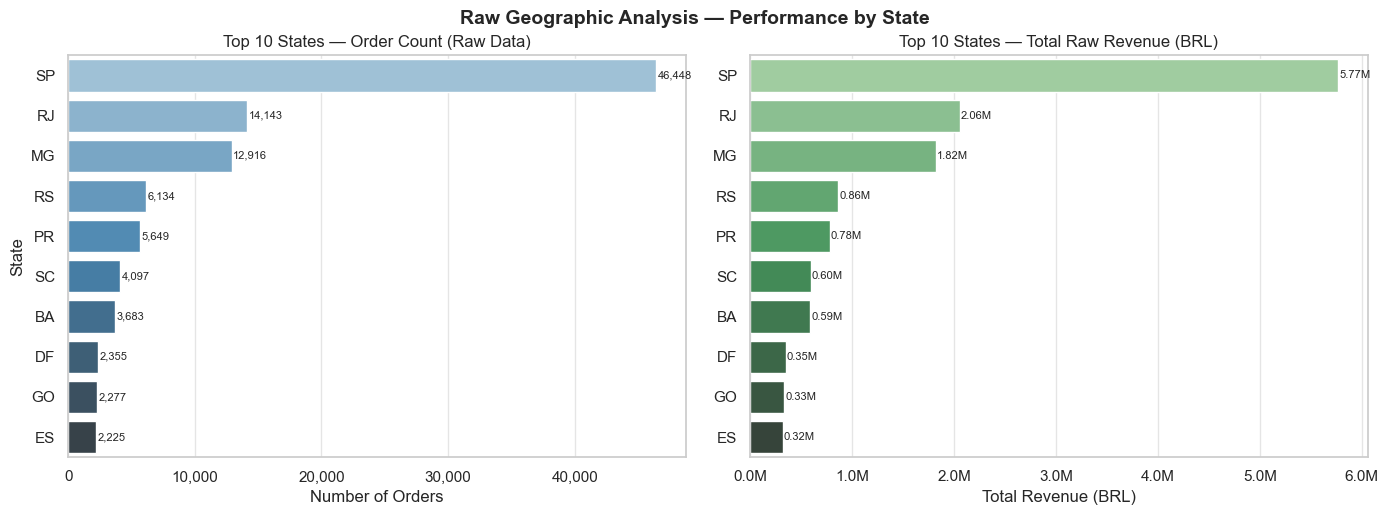

In [2]:
# ============================================================
# CHART: Raw Geographic Analysis — Top States by Orders & Revenue
# ============================================================
# Merge raw data tables
df_geo_raw = (
    olist_orders[['order_id', 'customer_id', 'order_status']]
    .merge(olist_customers[['customer_id', 'customer_state']], on='customer_id')
    .merge(olist_order_items[['order_id', 'price', 'freight_value']], on='order_id')
)

# Keep only delivered orders
df_geo_raw = df_geo_raw[df_geo_raw['order_status'] == 'delivered'].copy()
df_geo_raw['revenue'] = df_geo_raw['price'] + df_geo_raw['freight_value']

# Aggregate by raw state
state_summary_raw = (
    df_geo_raw.groupby('customer_state')
    .agg(order_count=('order_id', 'count'),
         total_revenue=('revenue', 'sum'))
    .reset_index()
    .sort_values('order_count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Top 10 states by order count ---
top10_orders_raw = state_summary_raw.nlargest(10, 'order_count')
sns.barplot(data=top10_orders_raw, x='order_count', y='customer_state',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Top 10 States — Order Count (Raw Data)')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('State')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, row in enumerate(top10_orders_raw.itertuples()):
    axes[0].text(row.order_count + 100, i, f'{row.order_count:,}', va='center', fontsize=8)

# --- Top 10 states by revenue ---
top10_rev_raw = state_summary_raw.nlargest(10, 'total_revenue')
sns.barplot(data=top10_rev_raw, x='total_revenue', y='customer_state',
            palette='Greens_d', ax=axes[1])
axes[1].set_title('Top 10 States — Total Raw Revenue (BRL)')
axes[1].set_xlabel('Total Revenue (BRL)')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, row in enumerate(top10_rev_raw.itertuples()):
    axes[1].text(row.total_revenue + 10000, i, f'{row.total_revenue/1e6:.2f}M', va='center', fontsize=8)

plt.tight_layout()
plt.suptitle('Raw Geographic Analysis — Performance by State', y=1.02, fontsize=14, fontweight='bold')
plt.show()


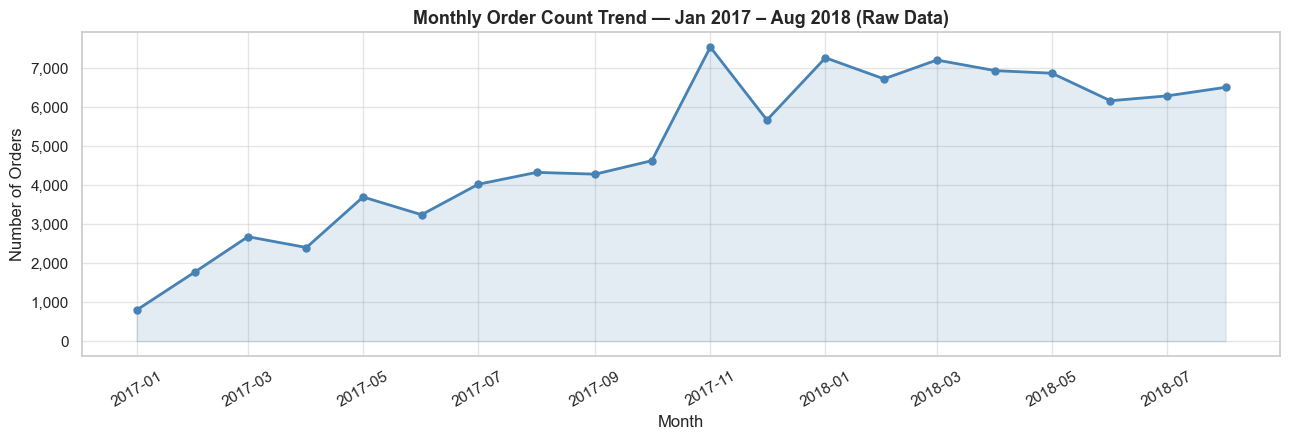

In [3]:
# ============================================================
# CHART: Monthly Order Count Trend (Raw Data)
# ============================================================
df_time_raw = olist_orders.copy()
df_time_raw['order_purchase_timestamp'] = pd.to_datetime(df_time_raw['order_purchase_timestamp'])
df_time_raw['order_month'] = df_time_raw['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

monthly_raw = (
    df_time_raw[df_time_raw['order_month'].between('2017-01-01', '2018-08-01')]
    .groupby('order_month')
    .agg(order_count=('order_id', 'count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(monthly_raw['order_month'], monthly_raw['order_count'],
        marker='o', linewidth=2, color='steelblue', markersize=5)
ax.fill_between(monthly_raw['order_month'], monthly_raw['order_count'], alpha=0.15, color='steelblue')
ax.set_title('Monthly Order Count Trend — Jan 2017 – Aug 2018 (Raw Data)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


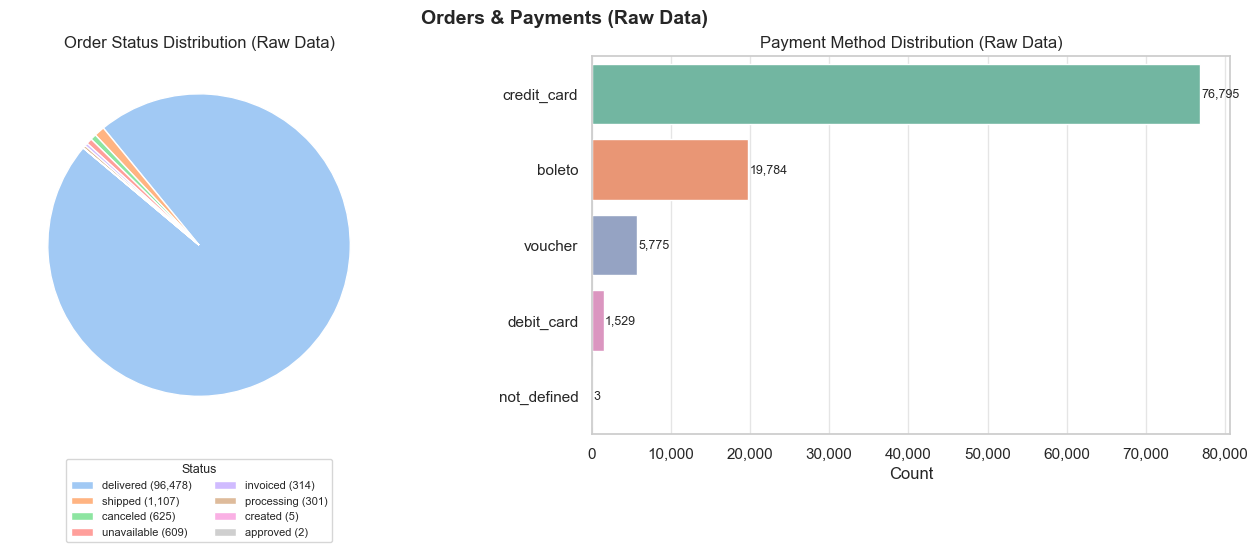

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Raw order status ---
status_counts = olist_orders['order_status'].value_counts()
colors_status = sns.color_palette('pastel', len(status_counts))

wedges, texts = axes[0].pie(
    status_counts.values,
    startangle=140,
    colors=colors_status,
    wedgeprops=dict(edgecolor='white')
)
for text in texts:
    text.set_visible(False)

axes[0].legend(
    wedges,
    [f'{label} ({val:,})' for label, val in zip(status_counts.index, status_counts.values)],
    title='Status',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    fontsize=8,
    title_fontsize=9
)
axes[0].set_title('Order Status Distribution (Raw Data)')

# --- Raw payment type ---
pay_counts = olist_order_payments['payment_type'].value_counts()
sns.barplot(x=pay_counts.values, y=pay_counts.index, palette='Set2', ax=axes[1])
axes[1].set_title('Payment Method Distribution (Raw Data)')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(pay_counts.values):
    axes[1].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Orders & Payments (Raw Data)', y=1.02, fontsize=14, fontweight='bold')
plt.show()


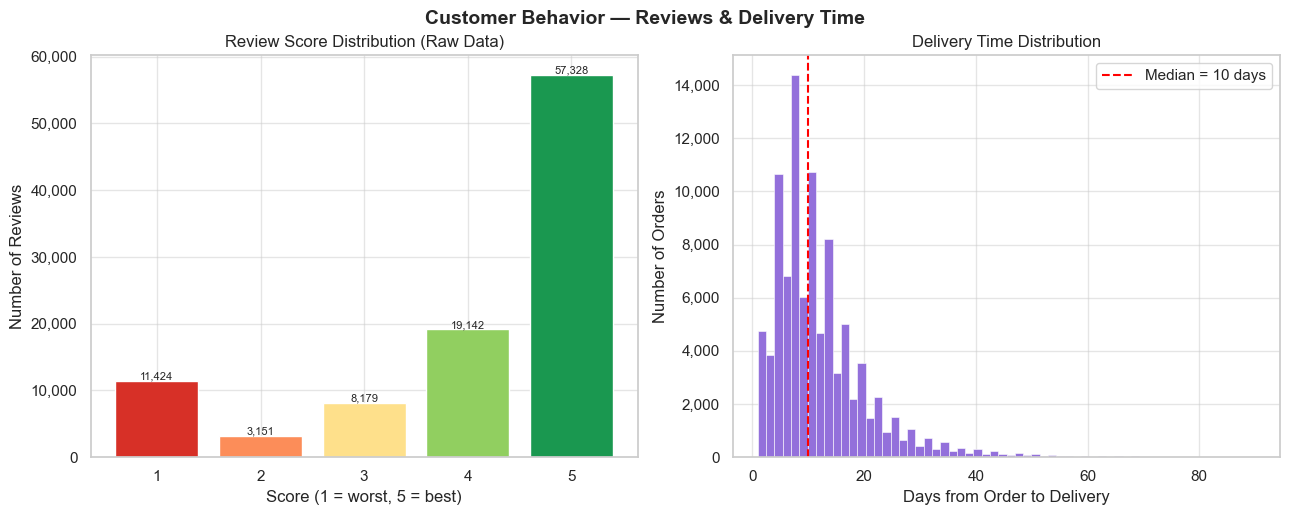

In [5]:
# ============================================================
# CHART: Customer Reviews & Delivery Time
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Review score ---
review_counts = olist_order_reviews['review_score'].value_counts().sort_index()
palette_review = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']
bars = axes[0].bar(review_counts.index.astype(str), review_counts.values,
                   color=palette_review, edgecolor='white')
axes[0].set_title('Review Score Distribution (Raw Data)')
axes[0].set_xlabel('Score (1 = worst, 5 = best)')
axes[0].set_ylabel('Number of Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, review_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=8)

# --- Delivery time ---
df_del = olist_orders[olist_orders['order_status'] == 'delivered'].copy()
df_del['order_purchase_timestamp']  = pd.to_datetime(df_del['order_purchase_timestamp'])
df_del['order_delivered_customer_date'] = pd.to_datetime(df_del['order_delivered_customer_date'])
df_del['delivery_days'] = (
    df_del['order_delivered_customer_date'] - df_del['order_purchase_timestamp']
).dt.days
df_del_clean = df_del.dropna(subset=['delivery_days'])
df_del_clean = df_del_clean[df_del_clean['delivery_days'].between(1, 90)]

axes[1].hist(df_del_clean['delivery_days'], bins=60, color='mediumpurple', edgecolor='white', linewidth=0.4)
median_days = df_del_clean['delivery_days'].median()
axes[1].axvline(median_days, color='red', linestyle='--', linewidth=1.5,
                label=f'Median = {median_days:.0f} days')
axes[1].set_title('Delivery Time Distribution')
axes[1].set_xlabel('Days from Order to Delivery')
axes[1].set_ylabel('Number of Orders')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.suptitle('Customer Behavior — Reviews & Delivery Time', y=1.02, fontsize=14, fontweight='bold')
plt.show()


---
# PART 2: PROCESSED DATA VISUALIZATION
---
In this section, we load the preprocessed files from the data cleaning pipeline to accurately reflect successful sales performance and remove logistics errors.


In [6]:
# ============================================================
# 1. READ PREPROCESSED DATA
# ============================================================
orders_clean = pd.read_csv(olist_processed_dir / 'orders.csv')
customers_clean = pd.read_csv(olist_processed_dir / 'customers.csv')

# Also read raw order_items to join revenue (since order_items only contains unchanged raw price and freight)
order_items_raw = pd.read_csv(olist_raw_dir / 'olist_order_items_dataset.csv')

# Merge tables
df_geo_processed = (
    orders_clean[['order_id', 'customer_id', 'order_status']]
    .merge(customers_clean[['customer_id', 'customer_state']], on='customer_id')
    .merge(order_items_raw[['order_id', 'price', 'freight_value']], on='order_id')
)
df_geo_processed['revenue'] = df_geo_processed['price'] + df_geo_processed['freight_value']


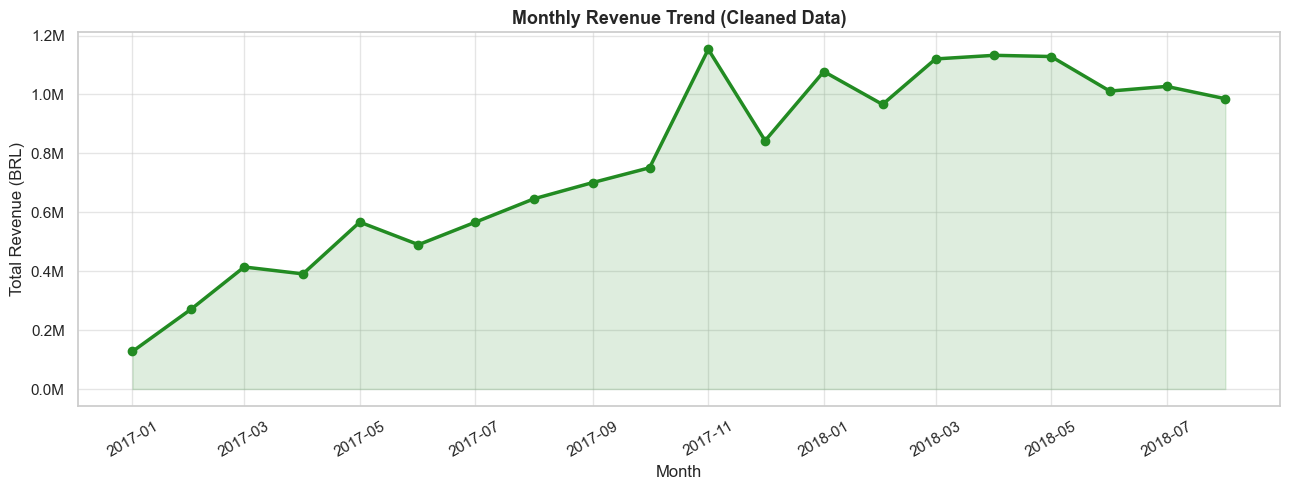

In [7]:
# ============================================================
# CHART: Monthly Revenue Trend (Jan 2017 – Aug 2018)
# ============================================================
df_time_processed = orders_clean.copy()
df_time_processed['order_purchase_timestamp'] = pd.to_datetime(df_time_processed['order_purchase_timestamp'])
df_time_processed['order_month'] = df_time_processed['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

df_time_revenue = (
    df_time_processed[['order_id', 'order_month']]
    .merge(order_items_raw[['order_id', 'price', 'freight_value']], on='order_id')
)
df_time_revenue['revenue'] = df_time_revenue['price'] + df_time_revenue['freight_value']

monthly_rev = (
    df_time_revenue[df_time_revenue['order_month'].between('2017-01-01', '2018-08-01')]
    .groupby('order_month')['revenue']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_rev['order_month'], monthly_rev['revenue'],
        marker='o', linewidth=2.5, color='forestgreen', markersize=6)
ax.fill_between(monthly_rev['order_month'], monthly_rev['revenue'], alpha=0.15, color='forestgreen')
ax.set_title('Monthly Revenue Trend (Cleaned Data)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (BRL)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


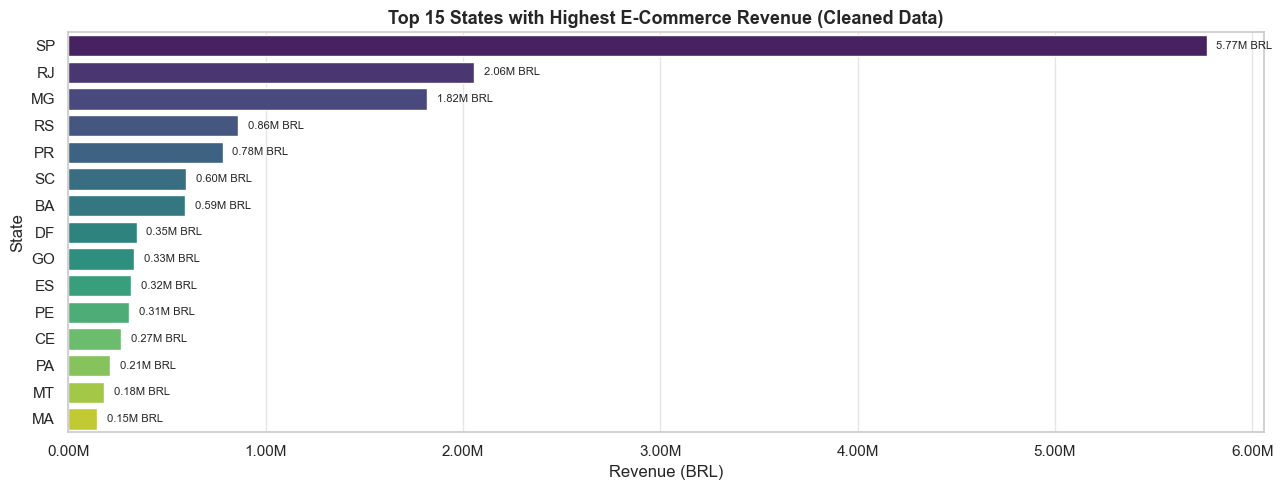

In [8]:
# ============================================================
# CHART: Total Revenue (Cleaned) by State
# ============================================================
state_summary_clean = (
    df_geo_processed.groupby('customer_state')['revenue']
    .sum()
    .reset_index()
    .sort_values('revenue', ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=state_summary_clean.head(15), x='revenue', y='customer_state',
            palette='viridis', ax=ax)
ax.set_title('Top 15 States with Highest E-Commerce Revenue (Cleaned Data)', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (BRL)')
ax.set_ylabel('State')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
for i, row in enumerate(state_summary_clean.head(15).itertuples()):
    ax.text(row.revenue + 50000, i, f'{row.revenue/1e6:.2f}M BRL', va='center', fontsize=8)
plt.tight_layout()
plt.show()


---
# PART 3: EXTERNAL DATA INTEGRATION & MARKET RESEARCH
---
In this section, we integrate additional Population (`population`) and GDP (`gdp`) data for **2017** from Brazil's IBGE source to compare the correlation between state market size and actual transaction performance on Olist.


In [9]:
# ============================================================
# LOAD & LINK POPULATION AND GDP DATA
# ============================================================
pib_df = pd.read_csv(external_dir / 'br_ibge_pib_uf.csv')
pop_df = pd.read_csv(external_dir / 'br_ibge_populacao_uf.csv')

# Use 2017 as the representative year
pib_2017 = pib_df[pib_df['year'] == 2017][['state', 'gdp']].copy()
pop_2017 = pop_df[pop_df['year'] == 2017][['state', 'population']].copy()
pop_2017 = pop_2017.dropna(subset=['state'])

# Aggregate cleaned Olist revenue by state
olist_state_rev = (
    df_geo_processed.groupby('customer_state')['revenue']
    .sum()
    .reset_index()
    .rename(columns={'customer_state': 'state'})
)

# Merge data
market_df = (
    olist_state_rev
    .merge(pib_2017, on='state')
    .merge(pop_2017, on='state')
)

# Calculate market survey metrics
market_df['revenue_per_capita'] = market_df['revenue'] / market_df['population']
market_df['gdp_per_capita'] = market_df['gdp'] / market_df['population']
# Penetration rate: Olist Revenue per 1 million BRL of state GDP
market_df['penetration_rate'] = market_df['revenue'] / (market_df['gdp'] / 1e6)

display(market_df.head(10))


,state,revenue,gdp,population,revenue_per_capita,gdp_per_capita,penetration_rate
0,AC,19575.33,1.427294e+10,829619,0.023596,17204.211324,1.371499
1,AL,94172.49,5.285107e+10,3375823,0.027896,15655.757703,1.781847
2,AM,27585.47,9.324019e+10,4063614,0.006788,22945.139701,0.295854
3,AP,16141.81,1.548191e+10,797722,0.020235,19407.648687,1.042624
4,BA,591137.81,2.687240e+11,15344447,0.038525,17512.784918,2.199795
5,CE,266436.77,1.479220e+11,9020460,0.029537,16398.498524,1.801198
6,DF,346123.35,2.447220e+11,3039444,0.113877,80515.383735,1.414353
7,ES,317657.93,1.134000e+11,4016356,0.079091,28234.548929,2.801216
8,GO,334212.35,1.919480e+11,6778772,0.049303,28316.043083,1.741161
9,MA,147803.55,8.954276e+10,7000229,0.021114,12791.404011,1.650648


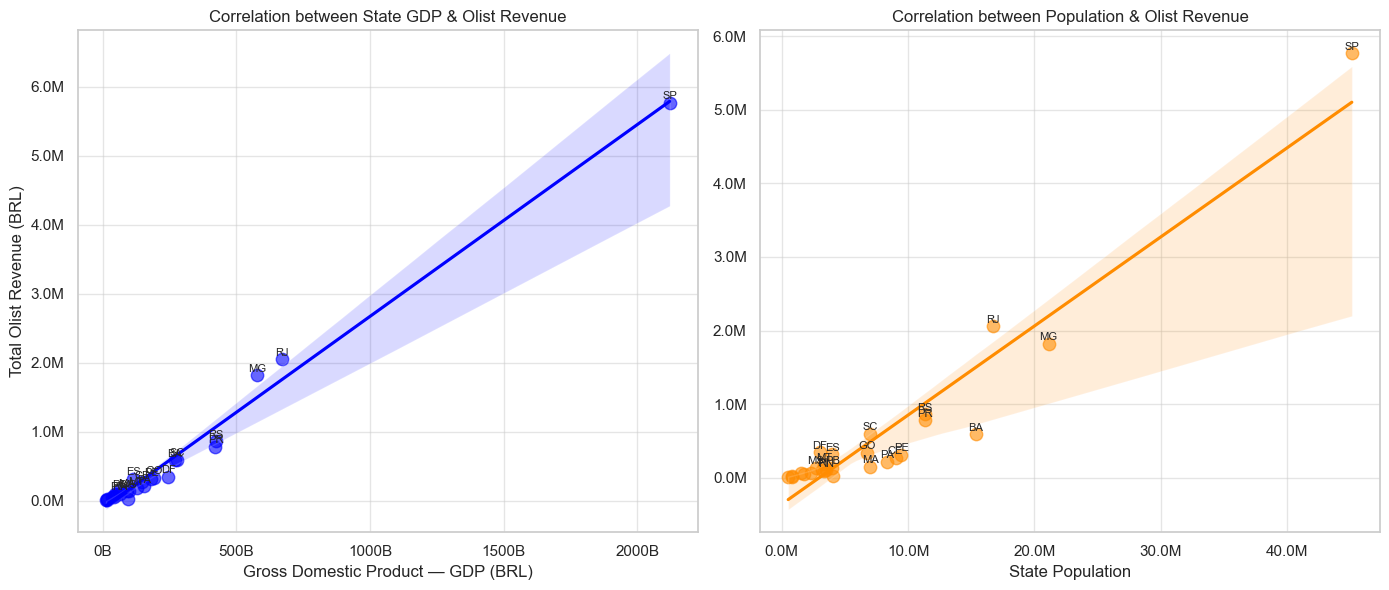

In [10]:
# ============================================================
# CHART: Correlation of GDP & Population with Olist Revenue
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. GDP vs Olist Revenue correlation
sns.regplot(data=market_df, x='gdp', y='revenue', ax=axes[0], color='blue',
            scatter_kws={'alpha':0.6, 's':80})
axes[0].set_title('Correlation between State GDP & Olist Revenue')
axes[0].set_xlabel('Gross Domestic Product — GDP (BRL)')
axes[0].set_ylabel('Total Olist Revenue (BRL)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for idx, row in market_df.iterrows():
    if row['revenue'] > 1e5 or row['gdp'] > 1e11:
        axes[0].text(row['gdp'], row['revenue'] + 50000, row['state'], fontsize=8, ha='center')

# 2. Population vs Olist Revenue correlation
sns.regplot(data=market_df, x='population', y='revenue', ax=axes[1], color='darkorange',
            scatter_kws={'alpha':0.6, 's':80})
axes[1].set_title('Correlation between Population & Olist Revenue')
axes[1].set_xlabel('State Population')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for idx, row in market_df.iterrows():
    if row['revenue'] > 1e5 or row['population'] > 1e7:
        axes[1].text(row['population'], row['revenue'] + 50000, row['state'], fontsize=8, ha='center')

plt.tight_layout()
plt.show()


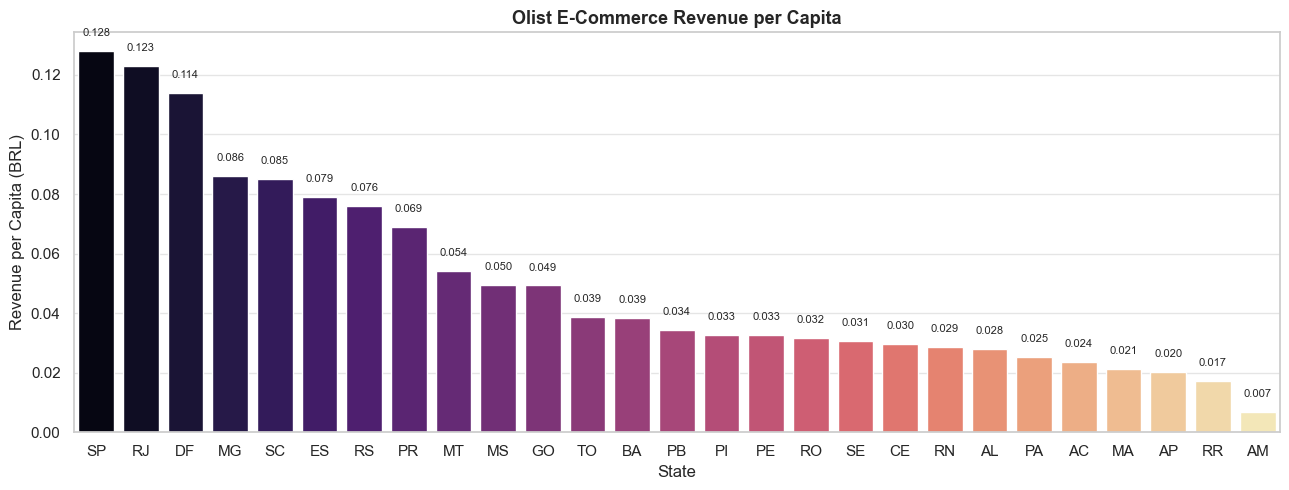

In [11]:
# ============================================================
# CHART: Olist Revenue per Capita by State
# ============================================================
market_df_sorted = market_df.sort_values('revenue_per_capita', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=market_df_sorted, x='state', y='revenue_per_capita', palette='magma', ax=ax)
ax.set_title('Olist E-Commerce Revenue per Capita', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Revenue per Capita (BRL)')
for i, row in enumerate(market_df_sorted.itertuples()):
    ax.text(i, row.revenue_per_capita + 0.005, f'{row.revenue_per_capita:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


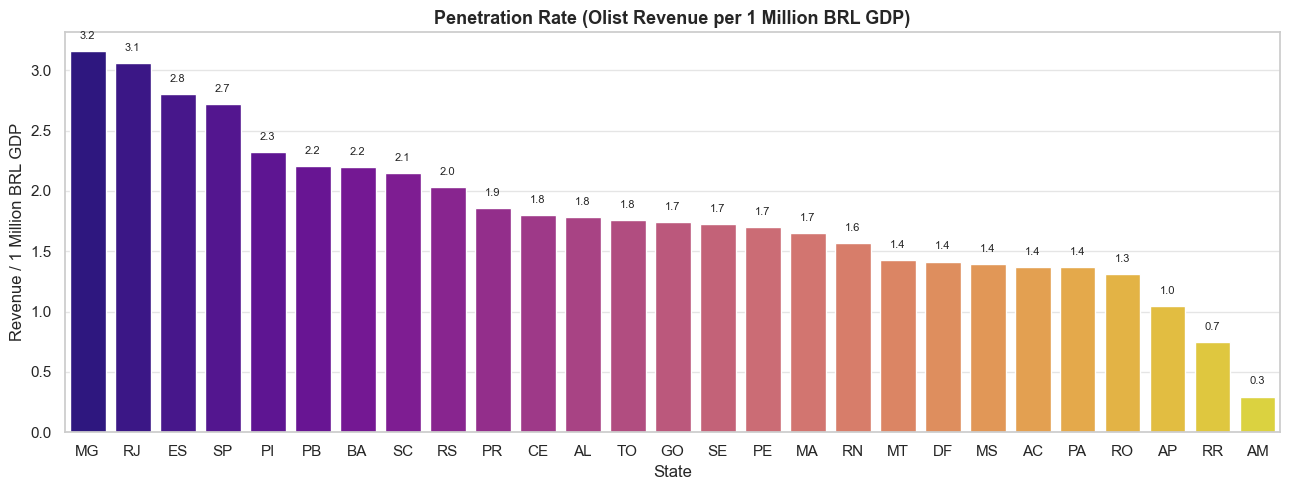

In [12]:
# ============================================================
# CHART: Penetration Rate (Revenue per Million BRL GDP)
# ============================================================
market_df_pene = market_df.sort_values('penetration_rate', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=market_df_pene, x='state', y='penetration_rate', palette='plasma', ax=ax)
ax.set_title('Penetration Rate (Olist Revenue per 1 Million BRL GDP)', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Revenue / 1 Million BRL GDP')
for i, row in enumerate(market_df_pene.itertuples()):
    ax.text(i, row.penetration_rate + 0.1, f'{row.penetration_rate:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


---
# PART 4: BRAZIL GEOSPATIAL CHOROPLETH MAPS
---
Using the locally stored GeoDataFrame at `data/external/br_states.geojson` to draw choropleth maps that visually reflect the density and market penetration opportunities of Olist.


In [13]:
# ============================================================
# LOAD BRAZIL GEOGRAPHIC DATA
# ============================================================
br_states = gpd.read_file(external_dir / 'br_states.geojson')

# Merge map data with economic/commercial data
br_map_df = br_states.merge(market_df, left_on='abbrev_state', right_on='state')
print("Shape of GeoDataFrame:", br_map_df.shape)


Shape of GeoDataFrame: (27, 13)


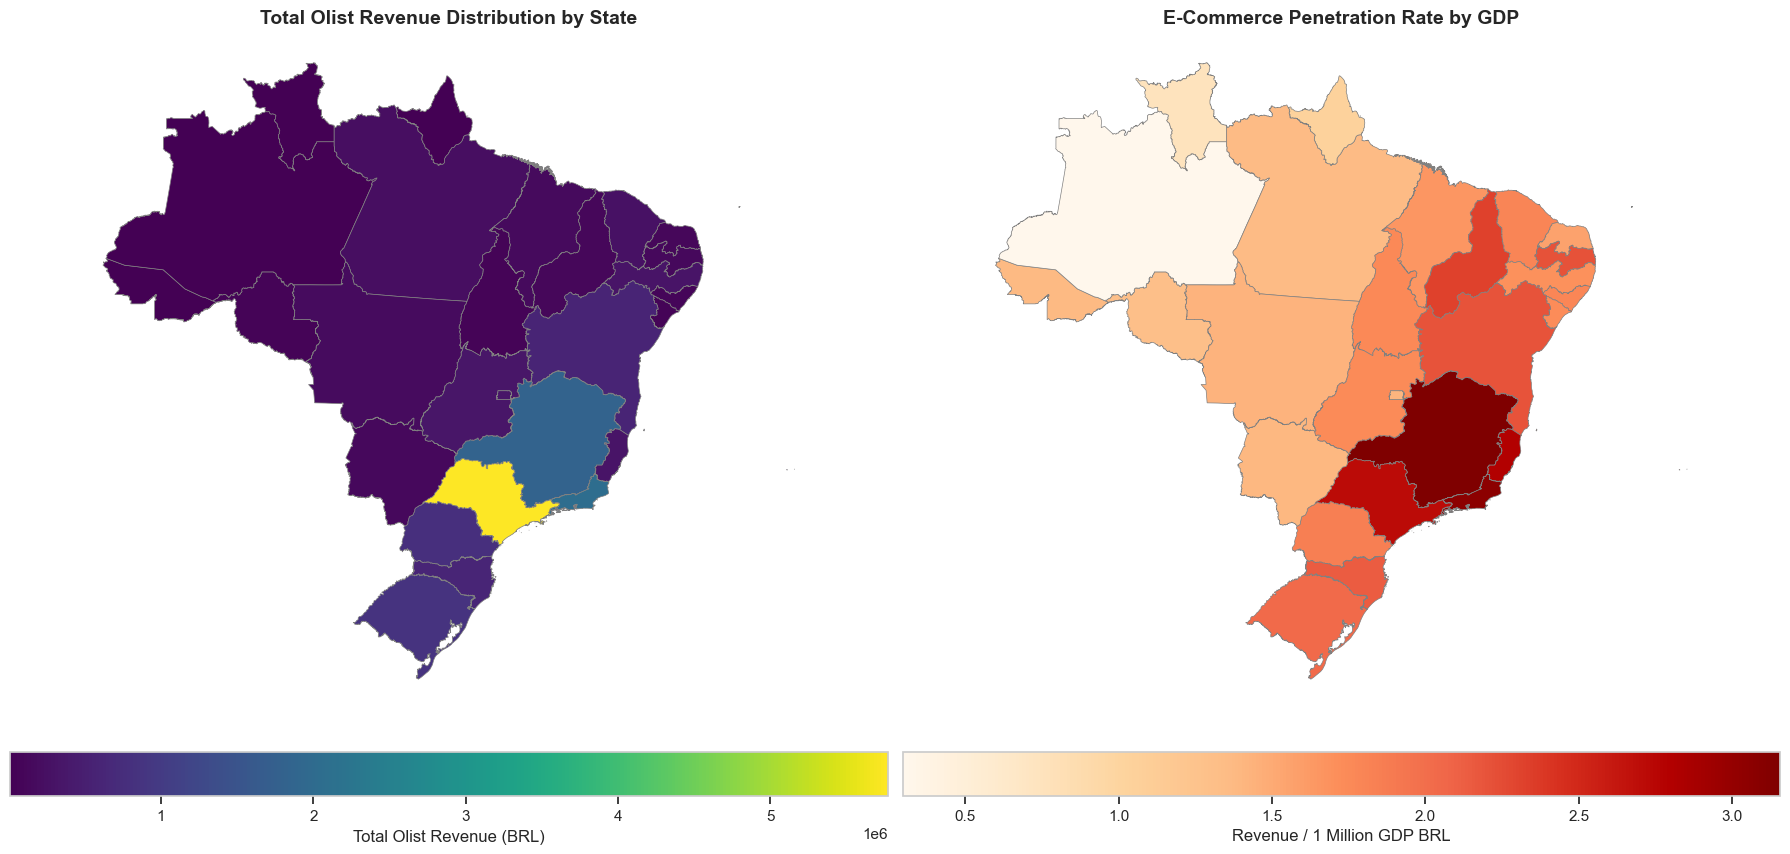

In [14]:
# ============================================================
# DRAW CHOROPLETH MAPS FOR REVENUE AND PENETRATION RATE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# 1. Total revenue by state map
br_map_df.plot(
    column='revenue',
    cmap='viridis',
    legend=True,
    legend_kwds={'label': "Total Olist Revenue (BRL)", 'orientation': "horizontal", 'pad': 0.05},
    ax=axes[0],
    edgecolor='gray',
    linewidth=0.5
)
axes[0].set_title('Total Olist Revenue Distribution by State', fontsize=14, fontweight='bold')
axes[0].axis('off')

# 2. Olist Revenue per 1 Million GDP map (Penetration Rate)
br_map_df.plot(
    column='penetration_rate',
    cmap='OrRd',
    legend=True,
    legend_kwds={'label': "Revenue / 1 Million GDP BRL", 'orientation': "horizontal", 'pad': 0.05},
    ax=axes[1],
    edgecolor='gray',
    linewidth=0.5
)
axes[1].set_title('E-Commerce Penetration Rate by GDP', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()
